In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata

## CARGAR EL DATASET LIMPIO Y CONFIGURA LO VISUAL


In [67]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

df = pd.read_csv("../data/processed/df_limpio.csv")

df.head()

,ID Estacion,Autoridad Ambiental,Estación,Latitud,Longitud,Variable,Unidades,Tiempo de exposición (horas),Año,Promedio,...,Mínimo,Fechas/horas del mínimo,Días de excedencias,Código del Departamento,Nombre del Departamento,Código del Municipio,Nombre del Municipio,Tipo de Estación,Ubicacion,tipo_outlier
0,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,DViento,deg,1,"2,011",256.8,...,1.3,29/11/2011 7:00,0,5,ANTIOQUIA,5308.0,GIRARDOTA,Fija,POINT (-75.443986 6.378517),Normal
1,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,DViento,deg,24,"2,011",257.4,...,99.7,8/11/2011 0:00,0,5,ANTIOQUIA,5308.0,GIRARDOTA,Fija,POINT (-75.443986 6.378517),Normal
2,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,PLiquida,mm,1,"2,011",4,...,1.5,07/11/2011 23:00:00 - 08/11/2011 05:00:00 - 13...,0,5,ANTIOQUIA,5308.0,GIRARDOTA,Fija,POINT (-75.443986 6.378517),Normal
3,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,P,mmHg,1,"2,011",645.9,...,641.6,27/10/2011 17:00,0,5,ANTIOQUIA,5308.0,GIRARDOTA,Fija,POINT (-75.443986 6.378517),Normal
4,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,P,mmHg,24,"2,011",645.9,...,644,27/10/2011 0:00,0,5,ANTIOQUIA,5308.0,GIRARDOTA,Fija,POINT (-75.443986 6.378517),Normal


# ANALISIS DE DISTRIBUCIÓN

Se realiza un analisis de las variables numericas mediante una grafica de histogramas y curvas, cuyo fin sera identificar sesgos o comportamientos anormales de los datos. 

### SELECCIONAMOS LAS COLUMNAS NUMERICAS QUE NOS DEN VALOR 

- Como revisamos en el notbook 02 algunas columnas no nos generan valor en las graficas, por lo tanto las excluimos en este analisis

In [68]:

excluir = [
    "Latitud",
    "Longitud",
    "Código del Departamento",
    "Código del Municipio"
]


columnas_numericas = df.select_dtypes(include=[np.number]).columns


columnas_analisis = [col for col in columnas_numericas if col not in excluir]

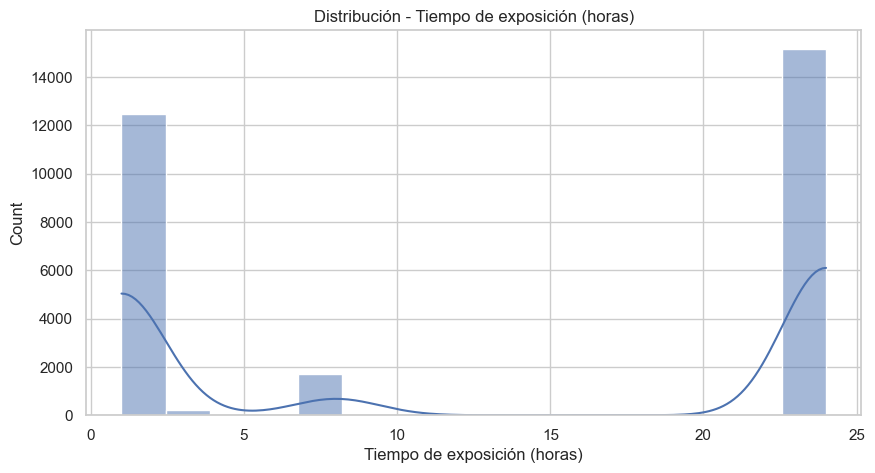

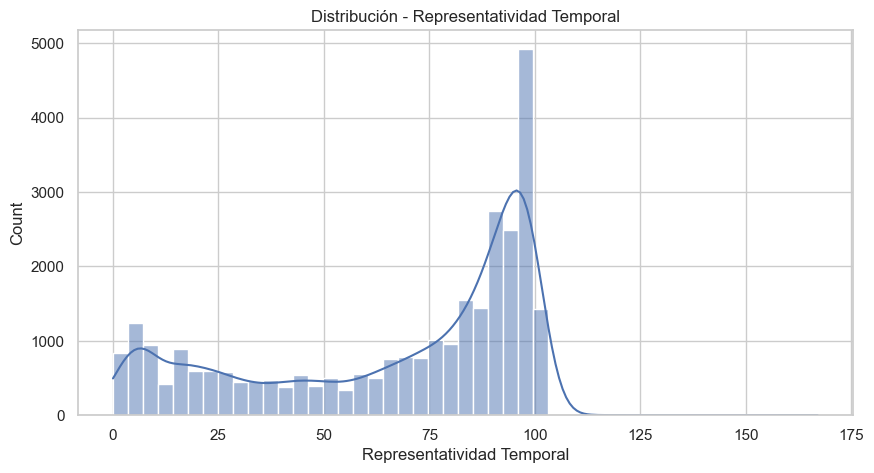

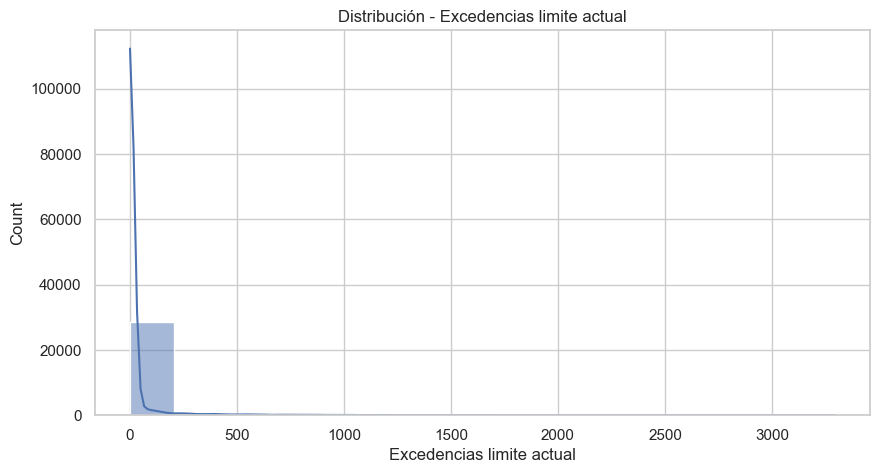

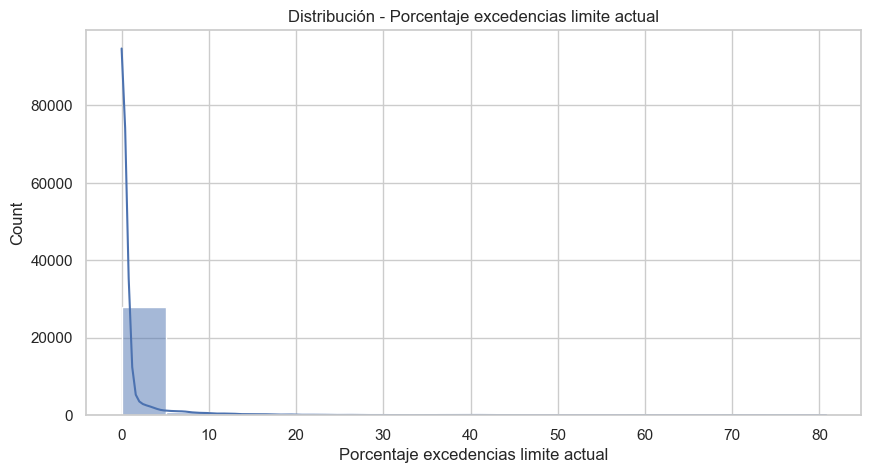

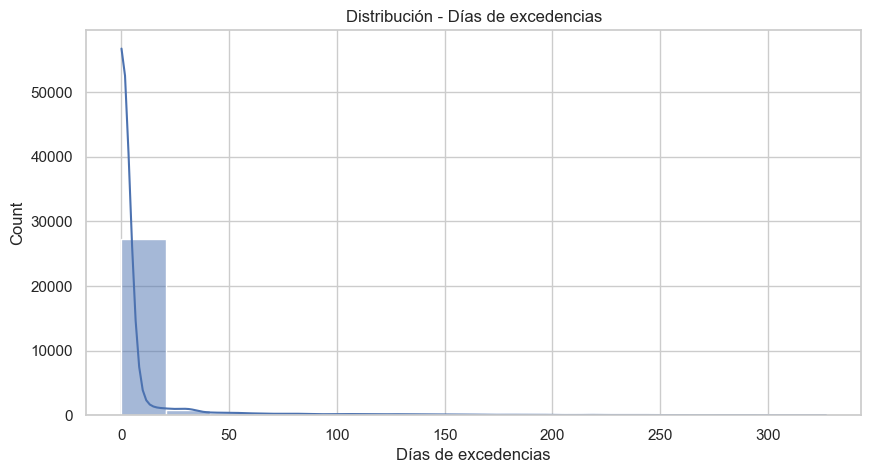

In [69]:
for col in columnas_analisis:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución - {col}")
    plt.show()

# CONCLUSIONES 

- Si miramos el Tiempo de exposición, vemos algo curioso: los datos se amontonan en los extremos. O son valores muy bajitos, o son de un día completo (24 horas). Esto sugiere que no todos los datos se recolectaron de la misma manera.
- En general, la calidad del tiempo en los registros es muy buena. La gran mayoría de los datos están bien cubiertos temporalmente, aunque todavía quedan algunos casos aislados que no son tan precisos.
- La mayoría de las veces los excesos son mínimos, pero los datos muestran casos aislados donde los límites se superan por mucho. Estos eventos extremos son pocos, pero muy marcados en comparación con el resto.
- La gran mayoría de los datos se concentran en valores bajos, pero tenemos una minoría de registros con niveles muy elevados.
- En la mayoría de los lugares los días con contaminación son pocos. Sin embargo, hay zonas específicas donde los excesos se repiten tanto que ya no son casos aislados, sino un problema constante y persistente.

En conjunto, estos resultados reflejan que los datos no siguen una distribución normal, lo cual es consistente con fenómenos ambientales donde los eventos extremos son poco frecuentes pero de alto impacto.

# ANÁLISIS UNIVARIADO

__Registros:__ 29531

La base de datos es consistente y no tenemos perdida de informacion ya que todas las columnas tienen la misma cantidad.

El análisis univariado permitió identificar que las variables relacionadas con la calidad del aire presentan distribuciones  sesgadas, con una gran concentración de valores en cero y la presencia de valores extremos.

Esto indica que la mayoría de los registros no presentan niveles críticos de contaminación, pero existen casos puntuales que reflejan condiciones severas.

En general el dataset muestra un comportamiento tipico de fenomenos ambientales, en donde los eventos extremos son pocos pero de alto impacto y poco frecuentes

In [70]:
df.describe()

,Latitud,Longitud,Tiempo de exposición (horas),Representatividad Temporal,Excedencias limite actual,Porcentaje excedencias limite actual,Días de excedencias,Código del Departamento,Código del Municipio
count,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,6.093463,-74.654829,13.236091,66.507094,29.050388,0.983751,7.203041,24.973181,25172.569232
std,2.143709,1.123821,11.180528,32.855428,153.559547,4.215890,28.879117,25.142155,25131.163686
min,1.216489,-77.283628,1.000000,0.000000,0.000000,0.000000,0.000000,5.000000,5001.000000
25%,4.631767,-75.581111,1.000000,39.000000,0.000000,0.000000,0.000000,5.000000,5579.000000
50%,5.897364,-74.222547,24.000000,81.000000,0.000000,0.000000,0.000000,11.000000,11001.000000
75%,6.409306,-74.030417,24.000000,94.000000,0.000000,0.000000,0.000000,44.000000,44078.000000
max,12.230000,-70.743889,24.000000,167.000000,3292.000000,80.770000,327.000000,85.000000,85001.000000


# NORMALIZACIÓN DE VARIABLES CATEGÓRICAS

Para facilitar el análisis, agrupamos la información por Municipio y Departamento. Al revisar los datos, detectamos algunas inconsistencias en los nombres, por lo que procedimos a normalizarlos. Esto nos asegura que el estudio sea sólido, preciso y libre de errores por duplicidad o mala escritura.

In [71]:
df["Nombre del Municipio"] = (
    df["Nombre del Municipio"]
    .str.strip()      # quitar espacios
    .str.lower()      # todo minúscula
)

df["Nombre del Departamento"] = (
    df["Nombre del Departamento"]
    .str.strip()      # quitar espacios
    .str.lower()      # todo minúscula
)

In [72]:
def quitar_tildes(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

df["Nombre del Municipio"] = df["Nombre del Municipio"].apply(quitar_tildes)
df["Nombre del Departamento"] = df["Nombre del Departamento"].apply(quitar_tildes)

In [73]:
df["Nombre del Departamento"] = df["Nombre del Departamento"].str.strip().str.title()
df["Nombre del Departamento"] = df["Nombre del Departamento"].str.title()

df["Nombre del Municipio"] = df["Nombre del Municipio"].str.strip().str.title()
df["Nombre del Municipio"] = df["Nombre del Municipio"].str.title()

In [74]:
columnas_categoricas = [
    "Nombre del Departamento",
    "Nombre del Municipio"
]

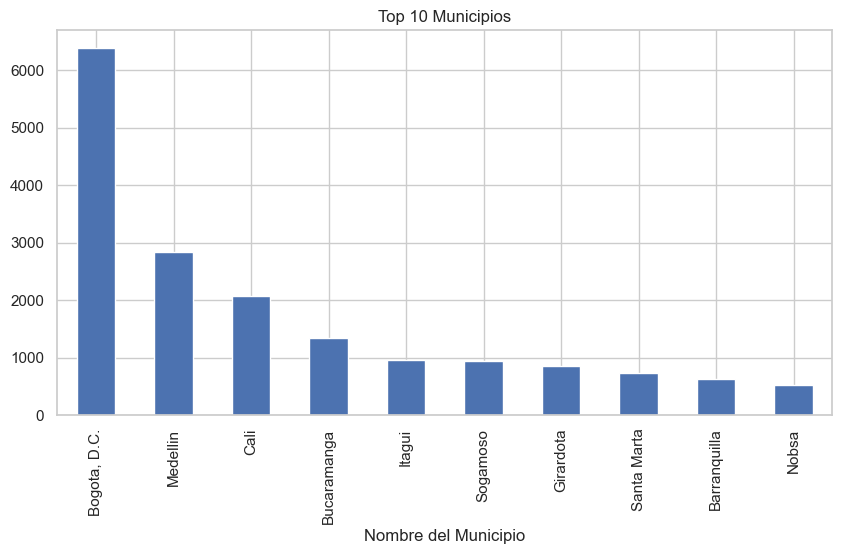

In [75]:
plt.figure()
df["Nombre del Municipio"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Municipios")
plt.xticks(rotation=90)
plt.show()

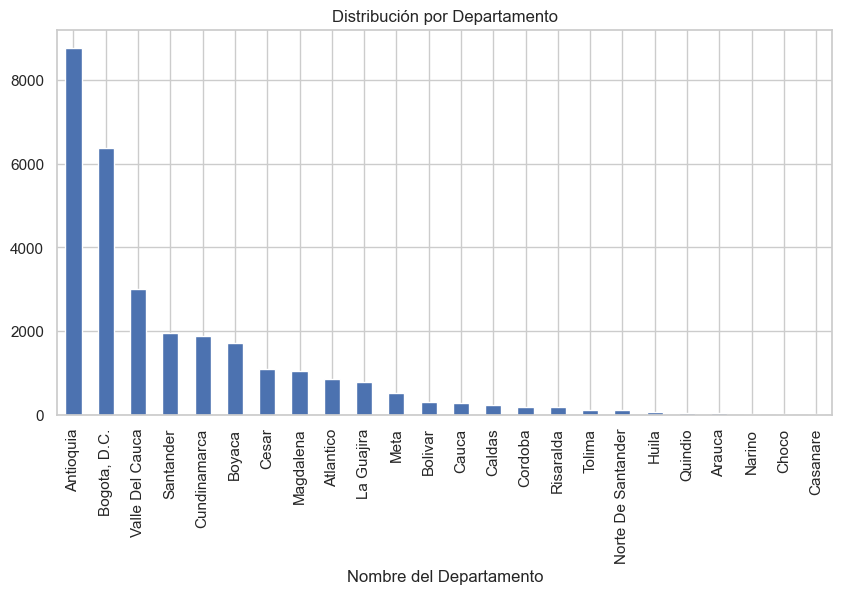

In [76]:
plt.figure()
df["Nombre del Departamento"].value_counts().plot(kind="bar")
plt.title("Distribución por Departamento")
plt.xticks(rotation=90)
plt.show()

# CONCLUSIONES VARIABLES CATEGÓRICAS

Observamos una conetración en ciudades principales como Bogotá, Medellín y Cali. 

Esto nos sugiere que el dataset presentó un enfoque mayor en el sector urbano  lo que pudo influir en los resultados presentados anteriormente y lo que podría describir esos picos de mayor contaminación en ciertos momentos.

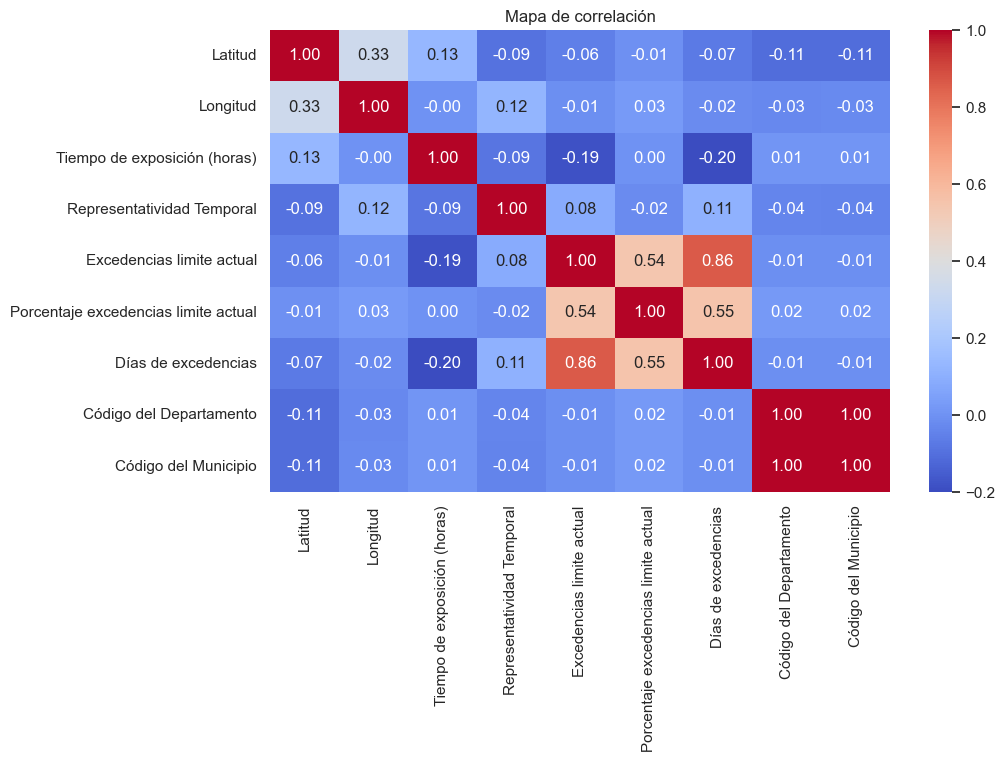

In [77]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de correlación")
plt.show()

# Análisis de correlación

El mapa de calor permite identificar relaciones significativas entre las variables numéricas del dataset.

Se observa una fuerte correlación positiva (0.86) entre el número de excedencias y los días de excedencias, lo que indica que ambas variables están directamente relacionadas y representan la frecuencia de eventos de contaminación.

Asimismo, el porcentaje de excedencias presenta una correlación moderada con estas variables, evidenciando que todas miden diferentes dimensiones del mismo fenómeno.

Por otro lado, variables como el tiempo de exposición y la representatividad temporal presentan correlaciones débiles, lo que sugiere que no tienen una influencia significativa sobre los niveles de contaminación.

Las variables geográficas (latitud y longitud) también muestran baja correlación, lo que indica que la ubicación por sí sola no explica el comportamiento de la contaminación.

Finalmente, las variables de código presentan correlaciones perfectas debido a su naturaleza como identificadores, por lo que no son relevantes para el análisis.

# Construcción de hipótesis

A partir del análisis exploratorio, se plantean las siguientes hipótesis:

1. Existe una relación positiva entre el número de excedencias y el porcentaje de excedencias en la calidad del aire.
2. Los municipios con mayor número de días de excedencias presentan niveles más altos de contaminación.
3. La distribución de la contaminación no es uniforme, existiendo zonas con concentraciones significativamente más altas.
4. Los valores extremos observados corresponden a eventos reales de contaminación y no a errores en los datos.
5. Las variables de contaminación presentan distribuciones sesgadas, lo que sugiere la presencia de eventos poco frecuentes pero de alto impacto.
